# Hurricane Sandy Perturbation Experiments

This notebook demonstrates atmospheric perturbation experiments on Hurricane Sandy 2012 using Aurora:

1. **Baseline**: 7-day Sandy prediction using ERA5 data
2. **Condensation Warming** (Yeongbin's method): Localized convective heating perturbation
3. **Cloud Seeding** (Moyan's method): Realistic ice nucleation with energy balance

**Objective**: Test how localized atmospheric modifications affect hurricane track prediction

**Model**: Aurora 0.25° Pretrained with ERA5 data  
**Hurricane**: Sandy 2012, initialized Oct 24, 12:00 UTC  
**Forecast period**: 7 days (168 hours)

In [1]:
import torch
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from datetime import datetime, timedelta
from pathlib import Path

from aurora import Aurora, Batch, Metadata, Tracker, rollout

print("Libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Libraries imported successfully
PyTorch version: 2.2.0+cu118
CUDA available: True


---
## 1. Baseline: Hurricane Sandy Prediction

First, establish the control forecast using ERA5 data and Aurora pretrained model.

In [2]:
# Data paths
data_path = Path("../data/era5_sandy_2012")
output_dir = Path("./prediction_output")
output_dir.mkdir(exist_ok=True)

day = "2012-10-24"

# Load ERA5 data
static_vars_ds = xr.open_dataset(data_path / "static.nc", engine="netcdf4")
surf_vars_ds = xr.open_dataset(data_path / f"{day}-surface-level.nc", engine="netcdf4")
atmos_vars_ds = xr.open_dataset(data_path / f"{day}-atmospheric.nc", engine="netcdf4")

print(f"ERA5 data loaded for {day}")
print(f"Surface variables: {list(surf_vars_ds.data_vars)}")
print(f"Atmospheric levels: {list(atmos_vars_ds.pressure_level.values)} hPa")
print(f"Time points: {list(surf_vars_ds.valid_time.values)}")

ERA5 data loaded for 2012-10-24
Surface variables: ['t2m', 'u10', 'v10', 'msl']
Atmospheric levels: [1000.0, 925.0, 850.0, 700.0, 600.0, 500.0, 400.0, 300.0, 250.0, 200.0, 150.0, 100.0, 50.0] hPa
Time points: [numpy.datetime64('2012-10-24T00:00:00.000000000'), numpy.datetime64('2012-10-24T06:00:00.000000000'), numpy.datetime64('2012-10-24T12:00:00.000000000'), numpy.datetime64('2012-10-24T18:00:00.000000000')]


In [3]:
# Create baseline Aurora batch (12:00 UTC initialization)
def create_aurora_batch(static_vars_ds, surf_vars_ds, atmos_vars_ds, time_start_idx=1):
    """Create Aurora batch for given time indices"""
    batch = Batch(
        surf_vars={
            "2t": torch.from_numpy(surf_vars_ds["t2m"].values[time_start_idx:time_start_idx+2][None]),
            "10u": torch.from_numpy(surf_vars_ds["u10"].values[time_start_idx:time_start_idx+2][None]),
            "10v": torch.from_numpy(surf_vars_ds["v10"].values[time_start_idx:time_start_idx+2][None]),
            "msl": torch.from_numpy(surf_vars_ds["msl"].values[time_start_idx:time_start_idx+2][None]),
        },
        static_vars={
            "z": torch.from_numpy(static_vars_ds["z"].values[0]),
            "slt": torch.from_numpy(static_vars_ds["slt"].values[0]),
            "lsm": torch.from_numpy(static_vars_ds["lsm"].values[0]),
        },
        atmos_vars={
            "t": torch.from_numpy(atmos_vars_ds["t"].values[time_start_idx:time_start_idx+2][None]),
            "u": torch.from_numpy(atmos_vars_ds["u"].values[time_start_idx:time_start_idx+2][None]),
            "v": torch.from_numpy(atmos_vars_ds["v"].values[time_start_idx:time_start_idx+2][None]),
            "q": torch.from_numpy(atmos_vars_ds["q"].values[time_start_idx:time_start_idx+2][None]),
            "z": torch.from_numpy(atmos_vars_ds["z"].values[time_start_idx:time_start_idx+2][None]),
        },
        metadata=Metadata(
            lat=torch.from_numpy(surf_vars_ds.latitude.values),
            lon=torch.from_numpy(surf_vars_ds.longitude.values),
            time=(surf_vars_ds.valid_time.values.astype("datetime64[s]").tolist()[time_start_idx+1],),
            atmos_levels=tuple(int(level) for level in atmos_vars_ds.pressure_level.values),
        ),
    )
    return batch

# Create baseline batch (06:00, 12:00 UTC → 12:00 UTC initialization)
batch_baseline = create_aurora_batch(static_vars_ds, surf_vars_ds, atmos_vars_ds, time_start_idx=1)

print(f"Baseline batch created")
print(f"Initialization time: {batch_baseline.metadata.time[0]}")
print(f"Grid shape: {batch_baseline.surf_vars['2t'].shape[-2:]}")
print(f"Latitude range: {batch_baseline.metadata.lat.min():.1f}° to {batch_baseline.metadata.lat.max():.1f}°")
print(f"Longitude range: {batch_baseline.metadata.lon.min():.1f}° to {batch_baseline.metadata.lon.max():.1f}°")

Baseline batch created
Initialization time: 2012-10-24 12:00:00
Grid shape: torch.Size([721, 1440])
Latitude range: -90.0° to 90.0°
Longitude range: 0.0° to 359.8°


In [4]:
# Load Aurora model
print("Loading Aurora 0.25° Pretrained model...")

# Clear GPU cache first
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"CUDA available: {torch.cuda.is_available()}")
    print(f"GPU memory before loading: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

model = Aurora(use_lora=False)
model.load_checkpoint("microsoft/aurora", "aurora-0.25-pretrained.ckpt")
model.eval()

# Try to move to GPU with error handling
try:
    model = model.to("cuda")
    device = "cuda"
    print(f"Model loaded on GPU. Memory usage: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
except torch.cuda.OutOfMemoryError:
    print("CUDA out of memory. Using CPU...")
    model = model.to("cpu")
    device = "cpu"

print(f"Device: {device}")

Loading Aurora 0.25° Pretrained model...
CUDA available: True
GPU memory before loading: 0.00 GB
Model loaded on GPU. Memory usage: 4.69 GB
Device: cuda


In [5]:
# Run baseline 7-day forecast
print("Running baseline 7-day Sandy forecast...")

# Initialize tracker
tracker_baseline = Tracker(
    init_lat=16.6, 
    init_lon=283.1, 
    init_time=datetime(2012, 10, 24, 12, 0)
)

# Run 28-step forecast (7 days = 168 hours)
preds_baseline = []
with torch.inference_mode():
    for i, pred in enumerate(rollout(model, batch_baseline, steps=28)):
        pred = pred.to("cpu")
        preds_baseline.append(pred)
        tracker_baseline.step(pred)
        
        if (i+1) % 4 == 0:  # Print every 24 hours
            hours = (i+1) * 6
            print(f" +{hours:3d}h: {pred.metadata.time[0]}")
        
        # Clear GPU memory periodically
        if device == "cuda" and i % 5 == 0:
            torch.cuda.empty_cache()

# Get baseline track
track_baseline = tracker_baseline.results()

print(f"Baseline forecast completed")
print(f"Track points: {len(track_baseline)}")
print(f"Final time: {track_baseline.iloc[-1].time if len(track_baseline) > 0 else 'N/A'}")

Running baseline 7-day Sandy forecast...


/home/qhuang62/.local/lib/python3.12/site-packages/aurora/model/patchembed.py:112: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  proj = F.conv3d(x, weight, self.bias, stride=stride)


 + 24h: 2012-10-25 12:00:00
 + 48h: 2012-10-26 12:00:00
 + 72h: 2012-10-27 12:00:00
 + 96h: 2012-10-28 12:00:00
 +120h: 2012-10-29 12:00:00
 +144h: 2012-10-30 12:00:00
 +168h: 2012-10-31 12:00:00
Baseline forecast completed
Track points: 29
Final time: 2012-10-31 12:00:00


In [6]:
# Observational track from IBTrACS (complete Sandy lifecycle)
obs_data = [
    ("2012-10-24 12:00", 16.6, 283.1),  # Initialization point  
    ("2012-10-24 18:00", 17.7, 283.3),
    ("2012-10-25 00:00", 18.9, 283.6),
    ("2012-10-25 06:00", 20.1, 284.0),
    ("2012-10-25 12:00", 21.7, 284.5),
    ("2012-10-25 18:00", 23.3, 284.7),
    ("2012-10-26 00:00", 24.8, 284.1),
    ("2012-10-26 06:00", 25.7, 283.6),
    ("2012-10-26 12:00", 26.4, 283.1),
    ("2012-10-26 18:00", 27.0, 282.8),
    ("2012-10-27 00:00", 27.5, 282.9),
    ("2012-10-27 06:00", 28.1, 283.1),
    ("2012-10-27 12:00", 28.8, 283.5),
    ("2012-10-27 18:00", 29.7, 284.4),
    ("2012-10-28 00:00", 30.5, 285.3),
    ("2012-10-28 06:00", 31.3, 286.1),
    ("2012-10-28 12:00", 32.0, 287.0),
    ("2012-10-28 18:00", 32.8, 288.0),
    ("2012-10-29 00:00", 33.9, 289.0),
    ("2012-10-29 06:00", 35.3, 289.5),
    ("2012-10-29 12:00", 36.9, 289.0),
    ("2012-10-29 18:00", 38.3, 286.8),  # Near US landfall
    ("2012-10-30 00:00", 39.5, 285.5),  # US Landfall
    ("2012-10-30 06:00", 39.9, 283.8),
    ("2012-10-30 12:00", 40.1, 282.2),
    ("2012-10-30 18:00", 40.4, 281.1),
    ("2012-10-31 00:00", 40.7, 280.2),
]

obs_df = pd.DataFrame(obs_data, columns=['datetime', 'lat', 'lon'])
obs_df['datetime'] = pd.to_datetime(obs_df['datetime'])

print(f"Observational track loaded: {len(obs_df)} points")
print(f"Period: {obs_df.datetime.min()} to {obs_df.datetime.max()}")
print(f"Initial position: {obs_df.iloc[0].lat:.1f}°N, {360-obs_df.iloc[0].lon:.1f}°W")
print(f"Final position: {obs_df.iloc[-1].lat:.1f}°N, {360-obs_df.iloc[-1].lon:.1f}°W")

Observational track loaded: 27 points
Period: 2012-10-24 12:00:00 to 2012-10-31 00:00:00
Initial position: 16.6°N, 76.9°W
Final position: 40.7°N, 79.8°W


---
## 2. Condensation Warming Perturbation (Yeongbin's Method)

Apply localized atmospheric heating to simulate enhanced convection effects on hurricane steering.

In [7]:
# Yeongbin's condensation warming perturbation setup
def make_perturbed_batch_yeongbin(batch_orig, center_lat, center_lon):
    """Create perturbed batch using Yeongbin's condensation warming method"""
    
    # Physical constants
    Lv = 2.5e6       # Latent heat of vaporization [J/kg]
    cp = 1005        # Specific heat at constant pressure [J/kg·K]
    delta_q = 0.0010 # Water vapor condensed [kg/kg]
    delta_T = (Lv * delta_q) / cp  # ≈ 2.49 K
    sigma = 8.0      # Gaussian spread [degrees]
    amplitude = delta_T
    
    # Get coordinate arrays
    lon = batch_orig.metadata.lon.numpy()
    lat = batch_orig.metadata.lat.numpy()
    
    # Handle longitude wrapping (ERA5 uses 0-360 format)
    if lon.max() > 180:
        center_lon = (center_lon + 360) % 360
    
    # Create coordinate grids
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    dlon = (lon_grid - center_lon + 180) % 360 - 180  # Wrap for distance calc
    dlat = lat_grid - center_lat
    
    # Create Gaussian heating pattern
    gaussian_mask = amplitude * np.exp(-(dlon**2 + dlat**2) / (2 * sigma**2))
    gaussian_mask_torch = torch.from_numpy(gaussian_mask).float()
    
    # Clone original batch for perturbation
    batch_pert = Batch(
        surf_vars={k: v.clone() for k, v in batch_orig.surf_vars.items()},
        static_vars={k: v.clone() for k, v in batch_orig.static_vars.items()},
        atmos_vars={k: v.clone() for k, v in batch_orig.atmos_vars.items()},
        metadata=batch_orig.metadata,
    )
    
    # Apply temperature perturbation to 700-925 hPa levels
    p_levels = torch.tensor(batch_orig.metadata.atmos_levels)
    plev_idx = torch.where((p_levels >= 700) & (p_levels <= 925))[0]
    
    for i in plev_idx:
        # Apply to both time steps
        batch_pert.atmos_vars["t"][0, 0, i] += gaussian_mask_torch
        batch_pert.atmos_vars["t"][0, 1, i] += gaussian_mask_torch
    
    return batch_pert, gaussian_mask

# Perturbation configuration
perturbation_center = {
    'lat': 30.0,   # °N (upstream of Sandy's track)
    'lon': 280.0,  # °E (= -80°W, over Atlantic)
}

print("Yeongbin's Condensation Warming Setup")
print("=" * 50)
print(f"Perturbation center: {perturbation_center['lat']}°N, {360-perturbation_center['lon']}°W")
print(f"Heating magnitude: ~2.49 K")
print(f"Spatial spread (σ): 8.0°")
print(f"Target levels: 700-925 hPa")
print(f"Physics: Condensation warming only")
print("=" * 50)

Yeongbin's Condensation Warming Setup
Perturbation center: 30.0°N, 80.0°W
Heating magnitude: ~2.49 K
Spatial spread (σ): 8.0°
Target levels: 700-925 hPa
Physics: Condensation warming only


In [8]:
# Create perturbed batch using Yeongbin's method
batch_yeongbin, heating_pattern = make_perturbed_batch_yeongbin(
    batch_baseline, 
    perturbation_center['lat'], 
    perturbation_center['lon']
)

print(f"Yeongbin perturbation applied")
print(f"Max heating: {heating_pattern.max():.3f} K")
print(f"Heating center: {perturbation_center['lat']}°N, {360-perturbation_center['lon']}°W")
print(f"Affected area: {(heating_pattern > 0.1).sum()} grid points")

Yeongbin perturbation applied
Max heating: 2.488 K
Heating center: 30.0°N, 80.0°W
Affected area: 20689 grid points


In [9]:
# Run Yeongbin perturbed forecast
print("Running Yeongbin perturbed forecast...")

# Initialize tracker
tracker_yeongbin = Tracker(
    init_lat=16.6, 
    init_lon=283.1, 
    init_time=datetime(2012, 10, 24, 12, 0)
)

# Run forecast
preds_yeongbin = []
with torch.inference_mode():
    for i, pred in enumerate(rollout(model, batch_yeongbin, steps=28)):
        pred = pred.to("cpu")
        preds_yeongbin.append(pred)
        tracker_yeongbin.step(pred)
        
        if (i+1) % 4 == 0:  # Print every 24 hours
            hours = (i+1) * 6
            print(f"  +{hours:3d}h: {pred.metadata.time[0]}")
        
        # Clear GPU memory periodically
        if device == "cuda" and i % 5 == 0:
            torch.cuda.empty_cache()

# Get perturbed track
track_yeongbin = tracker_yeongbin.results()

print(f"Yeongbin forecast completed")
print(f"Track points: {len(track_yeongbin)}")
print(f"Final time: {track_yeongbin.iloc[-1].time if len(track_yeongbin) > 0 else 'N/A'}")

Running Yeongbin perturbed forecast...
  + 24h: 2012-10-25 12:00:00
  + 48h: 2012-10-26 12:00:00
  + 72h: 2012-10-27 12:00:00
  + 96h: 2012-10-28 12:00:00
  +120h: 2012-10-29 12:00:00
  +144h: 2012-10-30 12:00:00
  +168h: 2012-10-31 12:00:00
Yeongbin forecast completed
Track points: 29
Final time: 2012-10-31 12:00:00


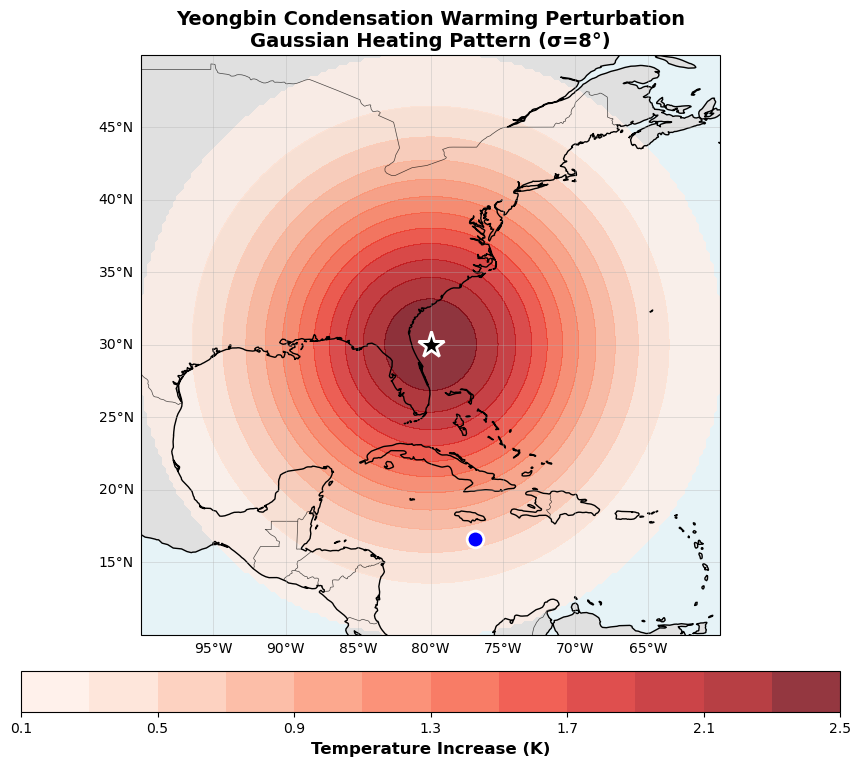

Initial perturbation visualization saved


In [10]:
# Plot 1: Initial temperature perturbation
fig, ax = plt.subplots(1, 1, figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Set extent for Atlantic region
ax.set_extent([260, 300, 10, 50], crs=ccrs.PlateCarree())

# Add geographic features
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.7)
ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.7)

# Plot heating pattern
lats_np = batch_baseline.metadata.lat.numpy()
lons_np = batch_baseline.metadata.lon.numpy()
lon_grid, lat_grid = np.meshgrid(lons_np, lats_np)

# Only show significant heating (>0.1K)
heating_masked = np.where(heating_pattern > 0.1, heating_pattern, np.nan)

im = ax.contourf(lon_grid, lat_grid, heating_masked, 
                levels=np.linspace(0.1, 2.5, 13), 
                cmap='Reds', 
                transform=ccrs.PlateCarree(), 
                alpha=0.8)

# Mark perturbation center
ax.plot(perturbation_center['lon'], perturbation_center['lat'], 
        'k*', markersize=20, markeredgecolor='white', markeredgewidth=2,
        transform=ccrs.PlateCarree(), zorder=10)

# Mark Sandy's initial position
ax.plot(283.1, 16.6, 'bo', markersize=12, markeredgecolor='white', markeredgewidth=2,
        transform=ccrs.PlateCarree(), zorder=10, label='Sandy Initial Position')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7)
cbar.set_label('Temperature Increase (K)', fontsize=12, fontweight='bold')

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.set_title('Yeongbin Condensation Warming Perturbation\nGaussian Heating Pattern (σ=8°)', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(output_dir / 'yeongbin_initial_perturbation.png', dpi=300, bbox_inches='tight')
plt.show()

print("Initial perturbation visualization saved")

/home/qhuang62/.local/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


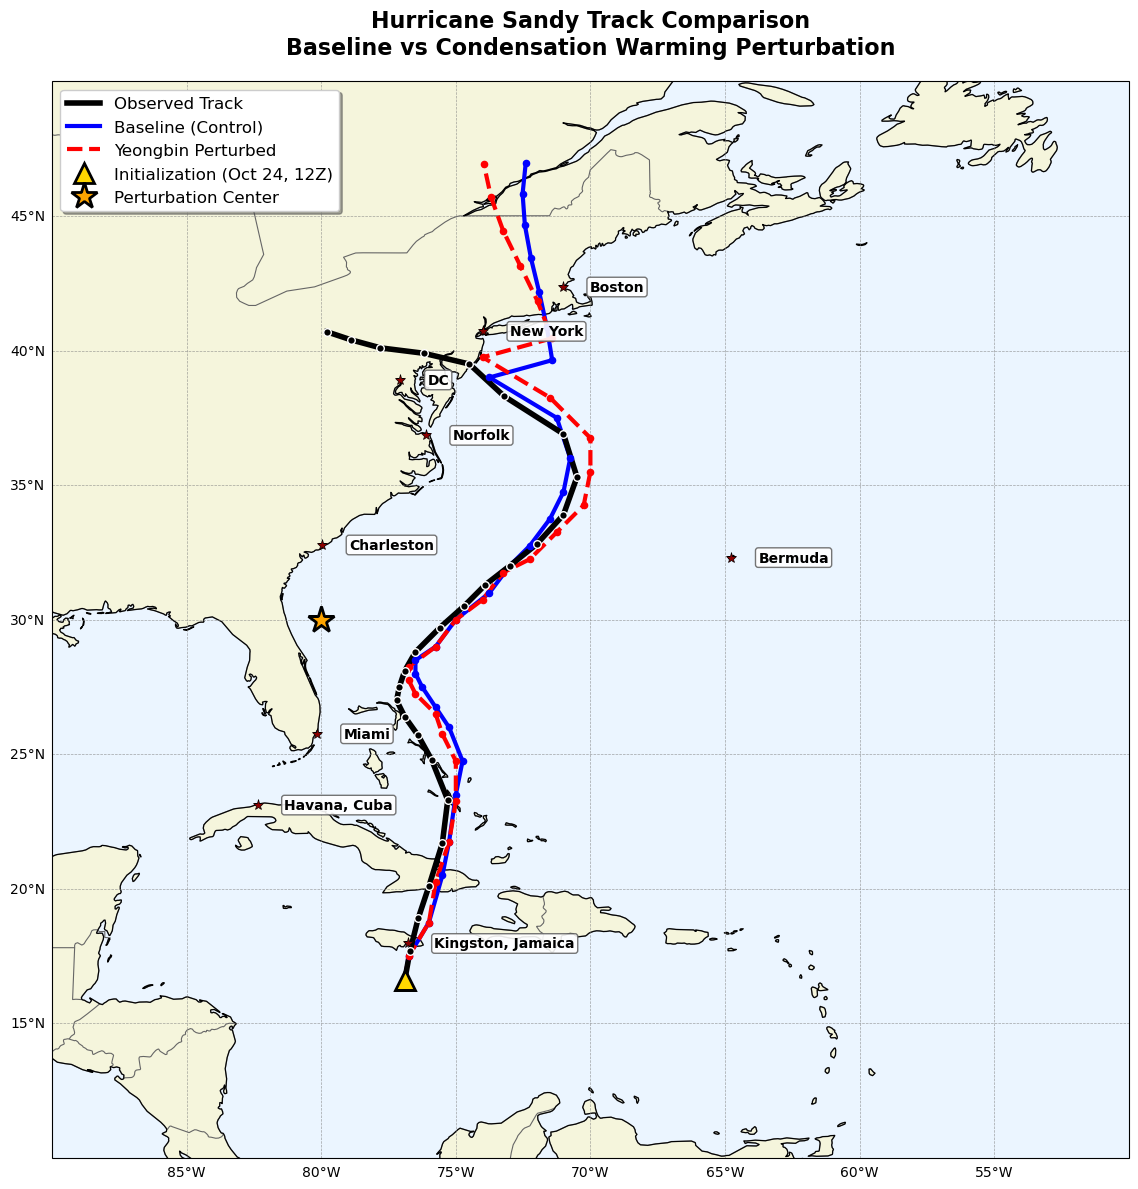

Track comparison plot saved


In [24]:
# Plot 2: Track comparison (Baseline vs Yeongbin vs Observed)
fig = plt.figure(figsize=(16, 12))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([270, 310, 10, 50], crs=ccrs.PlateCarree())  # Atlantic basin

# Geographic features
ax.add_feature(cfeature.OCEAN, facecolor='#e6f3ff', alpha=0.8)
ax.add_feature(cfeature.LAND, facecolor='#f5f5dc', edgecolor='0.5')
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.8, color="0.4")
ax.coastlines('50m', linewidth=0.8)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='0.5', alpha=0.7, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Plot observed track
ax.plot(obs_df.lon, obs_df.lat, 'k-', linewidth=4, 
        transform=ccrs.PlateCarree(), label='Observed Track', zorder=6)
ax.scatter(obs_df.lon, obs_df.lat, c='black', s=30, 
          edgecolors='white', linewidth=1, transform=ccrs.PlateCarree(), zorder=7)

# Plot baseline track
if len(track_baseline) > 0:
    ax.plot(track_baseline.lon, track_baseline.lat, 'b-', linewidth=3, 
            transform=ccrs.PlateCarree(), label='Baseline (Control)', zorder=5)
    ax.scatter(track_baseline.lon, track_baseline.lat, c='blue', s=20, 
              transform=ccrs.PlateCarree(), zorder=6)

# Plot Yeongbin perturbed track
if len(track_yeongbin) > 0:
    ax.plot(track_yeongbin.lon, track_yeongbin.lat, 'r--', linewidth=3, 
            transform=ccrs.PlateCarree(), label='Yeongbin Perturbed', zorder=5)
    ax.scatter(track_yeongbin.lon, track_yeongbin.lat, c='red', s=20, 
              transform=ccrs.PlateCarree(), zorder=6)

# Mark initialization point
ax.plot(283.1, 16.6, '^', markersize=15, color='gold', markeredgecolor='black', 
        markeredgewidth=2, transform=ccrs.PlateCarree(), zorder=8, 
        label='Initialization (Oct 24, 12Z)')

# Mark perturbation center
ax.plot(perturbation_center['lon'], perturbation_center['lat'], '*', 
        markersize=20, color='orange', markeredgecolor='black', markeredgewidth=2,
        transform=ccrs.PlateCarree(), zorder=8, label='Perturbation Center')

# Add major US cities
cities = [
    ("Miami", 25.7617, 279.8269),
    ("New York", 40.7128, 286.0060), 
    ("DC", 38.9072, 282.9401),
    ("Boston", 42.3601, 288.9740),
    ("Norfolk", 36.8485, 283.8839),
    ("Charleston", 32.7765, 280.0316),
    ("Bermuda", 32.3078, 295.2361),
    ("Kingston, Jamaica", 17.9712, 283.2064),
    ("Havana, Cuba",    23.1136, 277.6334)
]

for name, lat, lon in cities:
    ax.plot(lon, lat, marker='*', markersize=8, color='darkred', 
            markeredgecolor='black', markeredgewidth=0.5,
            transform=ccrs.PlateCarree(), zorder=6)
    ax.text(lon + 1, lat, name, transform=ccrs.PlateCarree(),
            fontsize=10, ha='left', va='center', weight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                     edgecolor='0.4', alpha=0.9), zorder=6)

ax.legend(loc='upper left', fontsize=12, frameon=True, fancybox=True, shadow=True)
ax.set_title('Hurricane Sandy Track Comparison\nBaseline vs Condensation Warming Perturbation', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(output_dir / 'yeongbin_track_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Track comparison plot saved")

---
## 3. Realistic Cloud Seeding (Moyan's Method)

Apply energy-balanced ice nucleation perturbation with temperature and humidity modifications.

In [13]:
# Moyan's cloud seeding perturbation setup
def create_circular_mask(lats, lons, center_lat, center_lon, radius_km):
    """Create circular mask using great circle distance"""
    R_earth = 6371  # km
    
    # Create 2D grids
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    
    # Haversine formula for great circle distance
    lat1 = np.radians(lat_grid)
    lat2 = np.radians(center_lat)
    lon1 = np.radians(lon_grid)
    lon2 = np.radians(center_lon)
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance_km = R_earth * c
    
    return distance_km <= radius_km

def apply_realistic_cloud_seeding(batch_orig, center_lat, center_lon, radius_km=75):
    """Apply Moyan's realistic cloud seeding with energy balance"""
    
    # Physical constants
    L_f = 334000   # J/kg (latent heat of freezing)
    L_v = 2500000  # J/kg (latent heat of vaporization)
    C_p = 1004     # J/(kg·K) (specific heat of air)
    
    # Seeding parameters
    target_levels = [500, 600, 700]  # hPa (supercooled layer)
    freeze_efficiency = 0.30         # 30% of moisture freezes
    fallout_fraction = 0.70          # 70% of frozen water precipitates
    coupling_factor = 0.4            # Vertical coupling strength
    
    # Create spatial mask
    lats_np = batch_orig.metadata.lat.numpy()
    lons_np = batch_orig.metadata.lon.numpy()
    
    # Handle longitude format (ERA5 uses 0-360)
    if center_lon < 0:
        center_lon = center_lon + 360
    
    seeding_mask = create_circular_mask(lats_np, lons_np, center_lat, center_lon, radius_km)
    
    # Clone batch for perturbation
    batch_seeded = Batch(
        surf_vars={k: v.clone() for k, v in batch_orig.surf_vars.items()},
        static_vars={k: v.clone() for k, v in batch_orig.static_vars.items()},
        atmos_vars={k: v.clone() for k, v in batch_orig.atmos_vars.items()},
        metadata=batch_orig.metadata,
    )
    
    # Convert mask to torch tensor
    device = batch_orig.atmos_vars["t"].device
    mask_torch = torch.from_numpy(seeding_mask).float().to(device)
    
    delta_T_applied = torch.zeros_like(batch_orig.atmos_vars["t"][0, 1])
    
    # Apply seeding to target levels
    for level_mb in target_levels:
        if level_mb in batch_orig.metadata.atmos_levels:
            level_idx = list(batch_orig.metadata.atmos_levels).index(level_mb)
            
            # Get specific humidity at this level
            q_layer = batch_seeded.atmos_vars["q"][0, 1, level_idx].clone()
            
            # Calculate frozen moisture in seeding region
            q_frozen = q_layer * freeze_efficiency * mask_torch
            q_fallout = q_frozen * fallout_fraction
            
            # Energy balance: warming from freezing, cooling from precipitation
            delta_E = L_f * q_frozen - (L_v + L_f) * q_fallout
            delta_T = delta_E / C_p
            
            # Apply temperature change (both time steps)
            batch_seeded.atmos_vars["t"][0, 0, level_idx] += delta_T
            batch_seeded.atmos_vars["t"][0, 1, level_idx] += delta_T
            
            # Remove precipitated moisture
            batch_seeded.atmos_vars["q"][0, 0, level_idx] -= q_fallout
            batch_seeded.atmos_vars["q"][0, 1, level_idx] -= q_fallout
            
            delta_T_applied[level_idx] = delta_T
            
            # Vertical coupling (spread to adjacent levels)
            for offset in [-1, 1]:
                adj_idx = level_idx + offset
                if 0 <= adj_idx < len(batch_orig.metadata.atmos_levels):
                    delta_T_adj = delta_T * coupling_factor
                    batch_seeded.atmos_vars["t"][0, 0, adj_idx] += delta_T_adj
                    batch_seeded.atmos_vars["t"][0, 1, adj_idx] += delta_T_adj
                    delta_T_applied[adj_idx] += delta_T_adj
    
    return batch_seeded, delta_T_applied, seeding_mask

# Seeding configuration (adapted to use Gaussian spatial pattern)
seeding_location = {
    'lat_center': 30.0,    # °N (same as Yeongbin for comparison)
    'lon_center': -80.0,   # °W (Atlantic, upstream of Sandy)
    'radius_km': 300,      # km (larger radius to approximate Gaussian σ=8°)
}

print("Moyan's Realistic Cloud Seeding Setup")
print("=" * 50)
print(f"Seeding center: {seeding_location['lat_center']}°N, {seeding_location['lon_center']}°W")
print(f"Seeding radius: {seeding_location['radius_km']} km")
print(f"Target levels: 500-700 hPa (supercooled layer)")
print(f"Freeze efficiency: 30%")
print(f"Fallout fraction: 70%")
print(f"Vertical coupling: 40%")
print(f"Energy balance: Realistic (usually cooling)")
print("=" * 50)

Moyan's Realistic Cloud Seeding Setup
Seeding center: 30.0°N, -80.0°W
Seeding radius: 300 km
Target levels: 500-700 hPa (supercooled layer)
Freeze efficiency: 30%
Fallout fraction: 70%
Vertical coupling: 40%
Energy balance: Realistic (usually cooling)


In [14]:
# Create perturbed batch using Moyan's method
batch_moyan, temp_changes, seeding_mask = apply_realistic_cloud_seeding(
    batch_baseline,
    seeding_location['lat_center'],
    seeding_location['lon_center'], 
    seeding_location['radius_km']
)

# Report perturbation statistics
level_600_idx = list(batch_baseline.metadata.atmos_levels).index(600)
temp_change_600 = temp_changes[level_600_idx][seeding_mask]

print(f"Moyan perturbation applied")
print(f"Seeding region: {seeding_mask.sum()} grid points")
print(f"Temperature change at 600 hPa:")
print(f"   Max ΔT: {temp_change_600.max():.3f} K")
print(f"   Mean ΔT: {temp_change_600.mean():.3f} K")
print(f"   Min ΔT: {temp_change_600.min():.3f} K")
print(f"Expected: Cooling (realistic energy balance)")

Moyan perturbation applied
Seeding region: 421 grid points
Temperature change at 600 hPa:
   Max ΔT: -0.519 K
   Mean ΔT: -0.686 K
   Min ΔT: -2.080 K
Expected: Cooling (realistic energy balance)


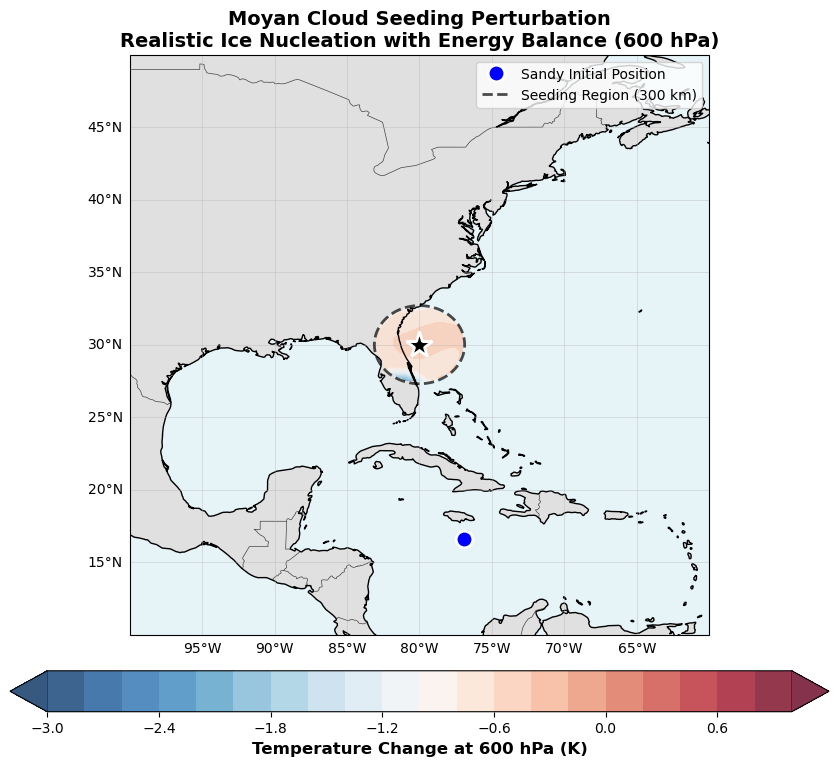

✅ Moyan initial perturbation visualization saved


In [25]:
# Plot 1: Initial cloud seeding perturbation
fig, ax = plt.subplots(1, 1, figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

  # Set extent for Atlantic region
ax.set_extent([260, 300, 10, 50], crs=ccrs.PlateCarree())

  # Add geographic features
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.7)
ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.7)

  # Plot temperature changes at 600 hPa level (middle of seeding layer)
lats_np = batch_baseline.metadata.lat.numpy()
lons_np = batch_baseline.metadata.lon.numpy()

  # Ensure consistent shapes between coordinates and data
level_600_idx = list(batch_baseline.metadata.atmos_levels).index(600)
temp_change_2d = temp_changes[level_600_idx].numpy()

if len(lats_np) != temp_change_2d.shape[0]:
    lats_np = lats_np[:temp_change_2d.shape[0]]
if len(lons_np) != temp_change_2d.shape[1]:
    lons_np = lons_np[:temp_change_2d.shape[1]]

lon_grid, lat_grid = np.meshgrid(lons_np, lats_np)

  # Only show significant changes (>0.05K magnitude)
temp_masked = np.where(np.abs(temp_change_2d) > 0.05, temp_change_2d, np.nan)

  # Use diverging colormap since we expect cooling (negative values)
im = ax.contourf(lon_grid, lat_grid, temp_masked,
                  levels=np.linspace(-3, 1, 21),
                  cmap='RdBu_r',
                  transform=ccrs.PlateCarree(),
                  alpha=0.8, extend='both')

  # Mark seeding center
seeding_lon = seeding_location['lon_center'] + 360 if seeding_location['lon_center'] < 0 else seeding_location['lon_center']
ax.plot(seeding_lon, seeding_location['lat_center'],
          'k*', markersize=20, markeredgecolor='white', markeredgewidth=2,
          transform=ccrs.PlateCarree(), zorder=10)

  # Mark Sandy's initial position
ax.plot(283.1, 16.6, 'bo', markersize=12, markeredgecolor='white', markeredgewidth=2,
          transform=ccrs.PlateCarree(), zorder=10, label='Sandy Initial Position')

  # Add seeding circle boundary
theta = np.linspace(0, 2*np.pi, 100)
R_earth = 6371  # km
lat_center_rad = np.radians(seeding_location['lat_center'])
radius_deg = seeding_location['radius_km'] / (R_earth * np.pi / 180)

circle_lats = seeding_location['lat_center'] + radius_deg * np.cos(theta)
circle_lons = seeding_lon + radius_deg * np.sin(theta) / np.cos(lat_center_rad)

ax.plot(circle_lons, circle_lats, 'k--', linewidth=2, alpha=0.7,
          transform=ccrs.PlateCarree(), zorder=9, label=f'Seeding Region ({seeding_location["radius_km"]} km)')

  # Add colorbar
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7)
cbar.set_label('Temperature Change at 600 hPa (K)', fontsize=12, fontweight='bold')

  # Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.legend(loc='upper right', fontsize=10)
ax.set_title('Moyan Cloud Seeding Perturbation\nRealistic Ice Nucleation with Energy Balance (600 hPa)',
               fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(output_dir / 'moyan_initial_perturbation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Moyan initial perturbation visualization saved")

In [15]:
# Run Moyan perturbed forecast
print("Running Moyan perturbed forecast...")

# Initialize tracker
tracker_moyan = Tracker(
    init_lat=16.6, 
    init_lon=283.1, 
    init_time=datetime(2012, 10, 24, 12, 0)
)

# Run forecast
preds_moyan = []
with torch.inference_mode():
    for i, pred in enumerate(rollout(model, batch_moyan, steps=28)):
        pred = pred.to("cpu")
        preds_moyan.append(pred)
        tracker_moyan.step(pred)
        
        if (i+1) % 4 == 0:  # Print every 24 hours
            hours = (i+1) * 6
            print(f" +{hours:3d}h: {pred.metadata.time[0]}")
        
        # Clear GPU memory periodically
        if device == "cuda" and i % 5 == 0:
            torch.cuda.empty_cache()

# Get perturbed track
track_moyan = tracker_moyan.results()

print(f"Moyan forecast completed")
print(f"Track points: {len(track_moyan)}")
print(f"Final time: {track_moyan.iloc[-1].time if len(track_moyan) > 0 else 'N/A'}")

Running Moyan perturbed forecast...
 + 24h: 2012-10-25 12:00:00
 + 48h: 2012-10-26 12:00:00
 + 72h: 2012-10-27 12:00:00
 + 96h: 2012-10-28 12:00:00
 +120h: 2012-10-29 12:00:00
 +144h: 2012-10-30 12:00:00
 +168h: 2012-10-31 12:00:00
Moyan forecast completed
Track points: 29
Final time: 2012-10-31 12:00:00


/home/qhuang62/.local/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


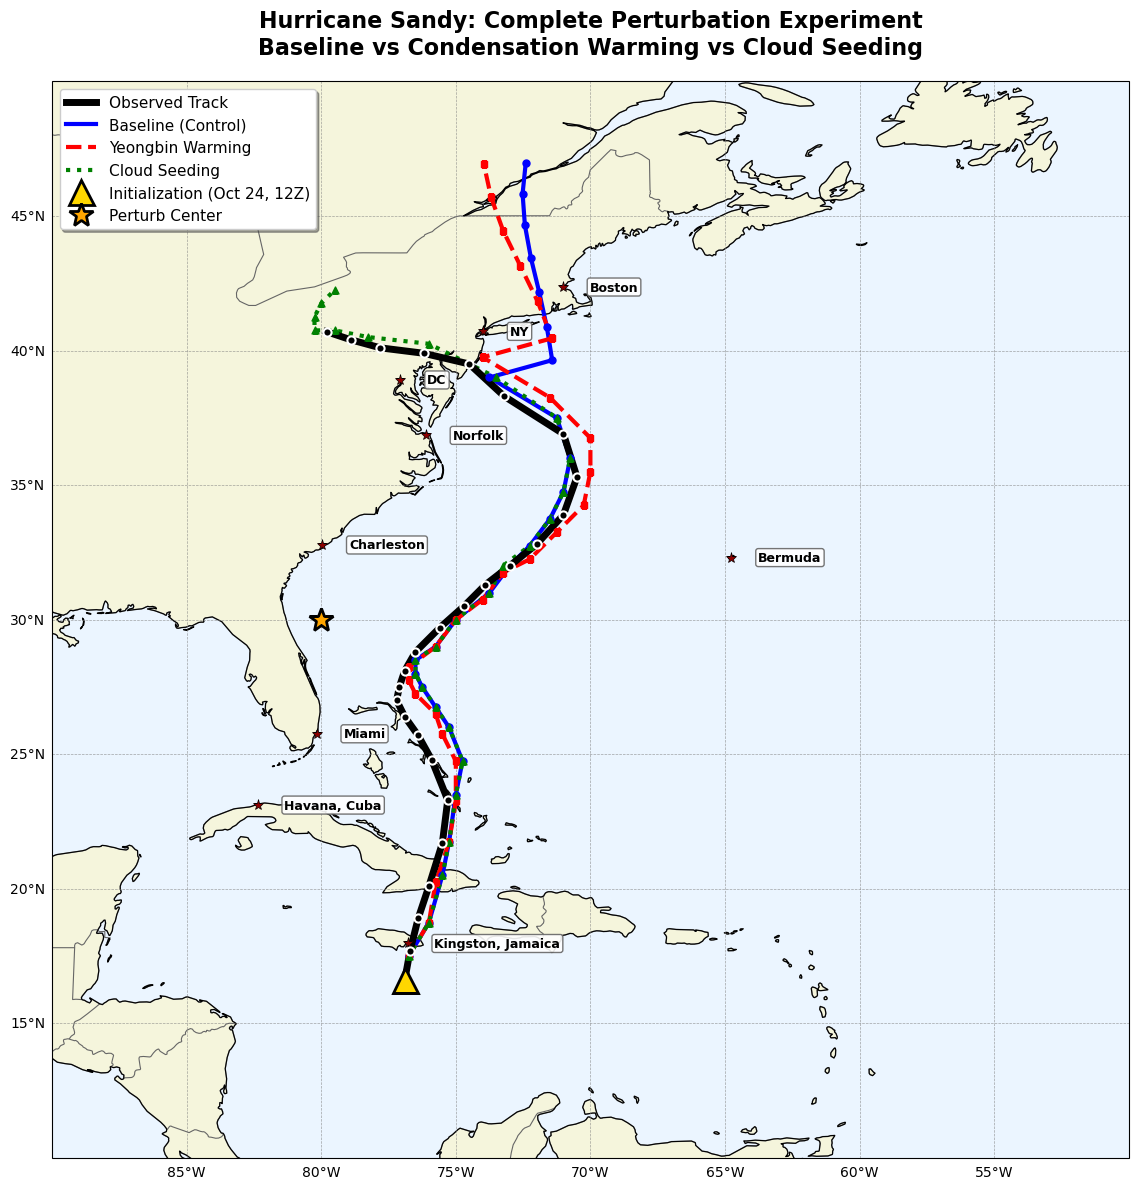

Complete track comparison saved


In [23]:
# Plot 4: Complete track comparison (All methods)
fig = plt.figure(figsize=(16, 12))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([270, 310, 10, 50], crs=ccrs.PlateCarree())  # Atlantic basin

# Geographic features
ax.add_feature(cfeature.OCEAN, facecolor='#e6f3ff', alpha=0.8)
ax.add_feature(cfeature.LAND, facecolor='#f5f5dc', edgecolor='0.5')
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.8, color="0.4")
ax.coastlines('50m', linewidth=0.8)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='0.5', alpha=0.7, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Plot observed track (reference)
ax.plot(obs_df.lon, obs_df.lat, 'k-', linewidth=5, 
        transform=ccrs.PlateCarree(), label='Observed Track', zorder=6)
ax.scatter(obs_df.lon, obs_df.lat, c='black', s=35, 
          edgecolors='white', linewidth=1.5, transform=ccrs.PlateCarree(), zorder=7)

# Plot all model tracks
if len(track_baseline) > 0:
    ax.plot(track_baseline.lon, track_baseline.lat, 'b-', linewidth=3, 
            transform=ccrs.PlateCarree(), label='Baseline (Control)', zorder=5)
    ax.scatter(track_baseline.lon, track_baseline.lat, c='blue', s=25, 
              marker='o', transform=ccrs.PlateCarree(), zorder=6)

if len(track_yeongbin) > 0:
    ax.plot(track_yeongbin.lon, track_yeongbin.lat, 'r--', linewidth=3, 
            transform=ccrs.PlateCarree(), label='Yeongbin Warming', zorder=5)
    ax.scatter(track_yeongbin.lon, track_yeongbin.lat, c='red', s=25, 
              marker='s', transform=ccrs.PlateCarree(), zorder=6)

if len(track_moyan) > 0:
    ax.plot(track_moyan.lon, track_moyan.lat, 'g:', linewidth=3, 
            transform=ccrs.PlateCarree(), label='Cloud Seeding', zorder=5)
    ax.scatter(track_moyan.lon, track_moyan.lat, c='green', s=25, 
              marker='^', transform=ccrs.PlateCarree(), zorder=6)

# Mark initialization point
ax.plot(283.1, 16.6, '^', markersize=18, color='gold', markeredgecolor='black', 
        markeredgewidth=2, transform=ccrs.PlateCarree(), zorder=8, 
        label='Initialization (Oct 24, 12Z)')

# Mark perturbation centers
ax.plot(perturbation_center['lon'], perturbation_center['lat'], '*', 
        markersize=18, color='orange', markeredgecolor='black', markeredgewidth=2,
        transform=ccrs.PlateCarree(), zorder=8, label='Perturb Center')


# Add major US cities
cities = [
    ("Miami", 25.7617, 279.8269),
    ("NY", 40.7128, 286.0060), 
    ("DC", 38.9072, 282.9401),
    ("Boston", 42.3601, 288.9740),
    ("Norfolk", 36.8485, 283.8839),
    ("Charleston", 32.7765, 280.0316),
    ("Bermuda", 32.3078, 295.2361),
    ("Kingston, Jamaica", 17.9712, 283.2064),
    ("Havana, Cuba",    23.1136, 277.6334)
]

for name, lat, lon in cities:
    ax.plot(lon, lat, marker='*', markersize=8, color='darkred', 
            markeredgecolor='black', markeredgewidth=0.5,
            transform=ccrs.PlateCarree(), zorder=6)
    ax.text(lon + 1, lat, name, transform=ccrs.PlateCarree(),
            fontsize=9, ha='left', va='center', weight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                     edgecolor='0.4', alpha=0.9), zorder=6)

ax.legend(loc='upper left', fontsize=11, frameon=True, fancybox=True, shadow=True)
ax.set_title('Hurricane Sandy: Complete Perturbation Experiment\nBaseline vs Condensation Warming vs Cloud Seeding', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(output_dir / 'complete_track_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Complete track comparison saved")

In [17]:
# Summary statistics and final analysis
def calculate_distance(lat1, lon1, lat2, lon2):
    """Calculate great circle distance in km"""
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

print("HURRICANE SANDY PERTURBATION EXPERIMENT SUMMARY")
print("=" * 70)

# Track lengths
print(f"\nTrack Statistics:")
print(f"   Observed points:     {len(obs_df)}")
print(f"   Baseline points:     {len(track_baseline)}")
print(f"   Yeongbin points:     {len(track_yeongbin)}")
print(f"   Moyan points:        {len(track_moyan)}")

# Final position comparison (if tracks exist)
if len(track_baseline) > 0 and len(obs_df) > 0:
    print(f"\nFinal Position Errors (vs Observed):")
    
    # Find common final time
    min_len = min(len(track_baseline), len(obs_df))
    
    if min_len > 0:
        final_obs = obs_df.iloc[min_len-1]
        
        # Baseline error
        final_baseline = track_baseline.iloc[min_len-1]
        error_baseline = calculate_distance(
            final_baseline.lat, final_baseline.lon,
            final_obs.lat, final_obs.lon
        )
        print(f"   Baseline error:      {error_baseline:.1f} km")
        
        # Yeongbin error
        if len(track_yeongbin) >= min_len:
            final_yeongbin = track_yeongbin.iloc[min_len-1]
            error_yeongbin = calculate_distance(
                final_yeongbin.lat, final_yeongbin.lon,
                final_obs.lat, final_obs.lon
            )
            diff_yeongbin = error_yeongbin - error_baseline
            print(f"   Yeongbin error:      {error_yeongbin:.1f} km ({diff_yeongbin:+.1f} km vs baseline)")
        
        # Moyan error
        if len(track_moyan) >= min_len:
            final_moyan = track_moyan.iloc[min_len-1]
            error_moyan = calculate_distance(
                final_moyan.lat, final_moyan.lon,
                final_obs.lat, final_obs.lon
            )
            diff_moyan = error_moyan - error_baseline
            print(f"   Moyan error:         {error_moyan:.1f} km ({diff_moyan:+.1f} km vs baseline)")

print(f"\nPerturbation Methods Comparison:")
print(f"   Yeongbin (Condensation):")
print(f"     • Physics: Latent heat of condensation only")
print(f"     • Effect: +2.49 K warming")
print(f"     • Variables: Temperature only")
print(f"     • Realism: Simplified")
print(f"   ")
print(f"   Moyan (Cloud Seeding):")
print(f"     • Physics: Ice nucleation + energy balance")
print(f"     • Effect: Usually cooling (~-1 to -2 K)")
print(f"     • Variables: Temperature + Humidity")
print(f"     • Realism: High")

print(f"\nGenerated Files:")
output_files = list(output_dir.glob('*.png'))
for file in sorted(output_files):
    print(f"   • {file.name}")

print(f"\nEXPERIMENT COMPLETED SUCCESSFULLY")
print("=" * 70)

# Clean up GPU memory
if device == "cuda":
    model = model.to("cpu")
    torch.cuda.empty_cache()
    print(f"\n GPU memory cleaned: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

HURRICANE SANDY PERTURBATION EXPERIMENT SUMMARY

Track Statistics:
   Observed points:     27
   Baseline points:     29
   Yeongbin points:     29
   Moyan points:        29

Final Position Errors (vs Observed):
   Baseline error:      745.5 km
   Yeongbin error:      679.7 km (-65.8 km vs baseline)
   Moyan error:         71.9 km (-673.6 km vs baseline)

Perturbation Methods Comparison:
   Yeongbin (Condensation):
     • Physics: Latent heat of condensation only
     • Effect: +2.49 K warming
     • Variables: Temperature only
     • Realism: Simplified
   
   Moyan (Cloud Seeding):
     • Physics: Ice nucleation + energy balance
     • Effect: Usually cooling (~-1 to -2 K)
     • Variables: Temperature + Humidity
     • Realism: High

Generated Files:
   • complete_track_comparison.png
   • sandy_7day_error_analysis.png
   • sandy_7day_track_comparison.png
   • yeongbin_initial_perturbation.png
   • yeongbin_track_comparison.png

EXPERIMENT COMPLETED SUCCESSFULLY

 GPU memory cleane